In [18]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [19]:
test_dict = {}
train_dict = {}
root_path = '../how_deep_is_your_thought/cifar-10-batches-py/'


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

accepted_keys = [b'labels', b'data'] ## select keys from [b'batch_label', b'labels', b'data', b'filenames']
for dir in os.listdir(root_path):
    if dir == 'batches.meta':
        pass
    elif dir == 'test_batch':
        test_batch = unpickle(os.path.join(root_path, dir))
        test_dict.update((k,np.array(v)) for k,v in test_batch.items() if k in accepted_keys)
    else:
        train_batch = unpickle(os.path.join(root_path, dir))
        if not train_dict:
            train_dict.update((k,np.array(v)) for k,v in train_batch.items() if k in accepted_keys)
        else:
            for key in accepted_keys:
                train_dict[key] = np.concatenate((train_dict[key], train_batch[key]), axis=0)


## CIFAR data's shape are (N, H*W*C). 
## If you want to convert them into numpy-standard (N, H, W, C) shape, run following codes.
def numpy2rgb(arr: np.ndarray) -> np.ndarray:
    batch_size = len(arr)
    arr = arr.reshape(batch_size, 3, 32, 32).transpose(0,2,3,1)
    
    return arr


train_dict[b'data'] = numpy2rgb(train_dict[b'data'])
test_dict[b'data'] = numpy2rgb(test_dict[b'data'])

In [20]:
def normalize(data: np.ndarray, mean: int=None, std: int=None) -> np.ndarray:
    if mean == None:
        mean = np.mean(data)
        
    if std == None:
        std = np.std(data)
    
    data = (data - mean) / std
    return data

In [21]:
x_train, t_train = normalize(train_dict[b'data']), train_dict[b'labels']
x_test, t_test = normalize(test_dict[b'data']), test_dict[b'labels']

print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(50000, 32, 32, 3)
2.0934103819959673
(50000,)


In [22]:
network_dict = {
                # 'relu': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='relu', weight_init_std=0.01),
                # 'my_relu': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='custom_relu', weight_init_std=0.01),
                'leaky': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [23]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [24]:
import time

output_dict = {}

for key, network in network_dict.items():
    start_time = time.time()

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
    
    running_time = time.time() - start_time
    print(f'running time is {running_time}')
    output_dict[f'{key} running time'] = running_time
    print('='*10)
    print('\n\n')



=== leaky network training start ===
--- leaky result report ---
train acc, test acc | 0.13202, 0.1346
--- leaky result report ---
train acc, test acc | 0.42628, 0.4204
--- leaky result report ---
train acc, test acc | 0.4657, 0.4458
--- leaky result report ---
train acc, test acc | 0.474, 0.4439
--- leaky result report ---
train acc, test acc | 0.49442, 0.4504
--- leaky result report ---
train acc, test acc | 0.5256, 0.4769
--- leaky result report ---
train acc, test acc | 0.51212, 0.4565
--- leaky result report ---
train acc, test acc | 0.53542, 0.4734
--- leaky result report ---
train acc, test acc | 0.53032, 0.4665
--- leaky result report ---
train acc, test acc | 0.55042, 0.4793
--- leaky result report ---
train acc, test acc | 0.56108, 0.4854
--- leaky result report ---
train acc, test acc | 0.55246, 0.4688
--- leaky result report ---
train acc, test acc | 0.56342, 0.4806
--- leaky result report ---
train acc, test acc | 0.56684, 0.4803
--- leaky result report ---
train acc, test

## simple normalization with relu

In [25]:
x_train, t_train = train_dict[b'data'] / 255.0, train_dict[b'labels']
x_test, t_test = test_dict[b'data'] / 255.0, test_dict[b'labels']

In [26]:
network_dict = {
                'relu': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='relu', weight_init_std=0.01),
                # 'my_relu': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='custom_relu', weight_init_std=0.01),
                # 'leaky': MultiLayerNetExtend(input_size=3*32*32, hidden_size_list=[50], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [27]:
# 하이퍼 파라메터
iters_num = 50_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [28]:
import time

# output_dict = {}

for key, network in network_dict.items():
    start_time = time.time()

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
    
    running_time = time.time() - start_time
    print(f'running time is {running_time}')
    output_dict[f'{key} running time'] = running_time
    print('='*10)
    print('\n\n')



=== relu network training start ===


--- relu result report ---
train acc, test acc | 0.10668, 0.1072
--- relu result report ---
train acc, test acc | 0.32086, 0.3216
--- relu result report ---
train acc, test acc | 0.37788, 0.3752
--- relu result report ---
train acc, test acc | 0.38452, 0.3811
--- relu result report ---
train acc, test acc | 0.41484, 0.4133
--- relu result report ---
train acc, test acc | 0.4102, 0.402
--- relu result report ---
train acc, test acc | 0.4307, 0.4232
--- relu result report ---
train acc, test acc | 0.4446, 0.4401
--- relu result report ---
train acc, test acc | 0.46144, 0.4455
--- relu result report ---
train acc, test acc | 0.4517, 0.4387
--- relu result report ---
train acc, test acc | 0.43452, 0.4243
--- relu result report ---
train acc, test acc | 0.41474, 0.4031
--- relu result report ---
train acc, test acc | 0.48034, 0.4606
--- relu result report ---
train acc, test acc | 0.4768, 0.4571
--- relu result report ---
train acc, test acc | 0.48266, 0.4522
--- relu result report ---
trai

In [29]:
output_dict.keys()

dict_keys(['leaky train acc', 'leaky test acc', 'leaky running time', 'relu train acc', 'relu test acc', 'relu running time'])

In [33]:
relu_running_time = output_dict.pop('relu running time')
leaky_running_time = output_dict.pop('leaky running time')

In [34]:
print(relu_running_time, leaky_running_time)

419.81268644332886 420.1131920814514


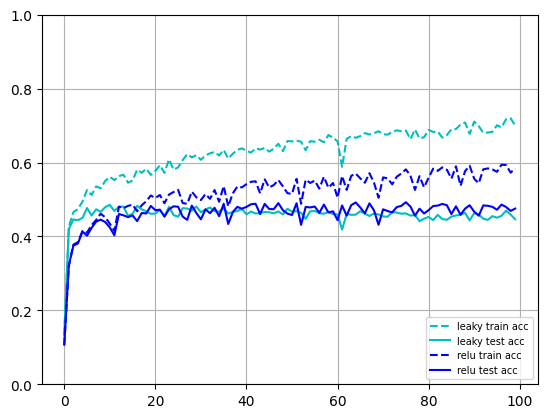

In [35]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend(loc='lower right', prop={'size':7})
plt.grid()